In [1]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [2]:
#Load Dataset
(x_train,_),(x_test,_)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [4]:
#Normalize Images
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255
x_train=np.reshape(x_train,(len(x_train),28,28,1))
x_test=np.reshape(x_test,(len(x_test),28,28,1))


In [7]:
#Adding Noise
noise_factor=0.5
x_train_noisy=x_train+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_train.shape)
x_test_noisy=x_test+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_test.shape)
x_train_noisy=np.clip(x_train_noisy,0.,1.)
x_test_noisy=np.clip(x_test_noisy,0.,1.)


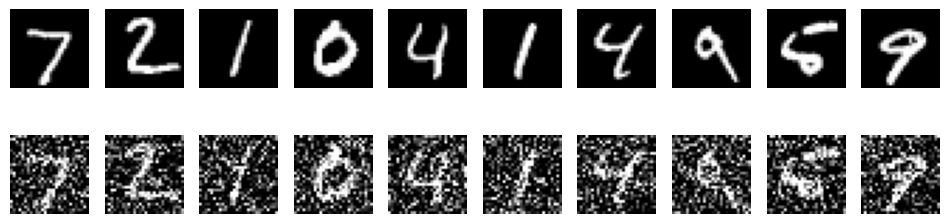

In [8]:
#Display Noisy Images
plt.figure(figsize=(12,3))
for i in range(10):
  ax=plt.subplot(2,10,i+1)
  plt.imshow(x_test[i].reshape(28,28),cmap='grey')
  plt.axis("off")
  ax=plt.subplot(2,10,i+11)
  plt.imshow(x_test_noisy[i].reshape(28,28),cmap='grey')
  plt.axis("off")
plt.show()

In [9]:
#Build Autoencoder'
input_img=Input(shape=(28,28,1))
#Encoder
x=Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x=MaxPooling2D((2,2),padding='same')(x)
x=Conv2D(32,(3,3),activation='relu',padding='same')(x)
encoded=MaxPooling2D((2,2),padding='same')(x)
#Decoder
x = Conv2D(32,(3,3),activation='relu',padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)

autoencoder = Model(input_img,decoded)



In [10]:
#Compile Model
autoencoder.compile(
    optimizer='adam',loss='binary_crossentropy'
)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#Train Model
history=autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy,x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 300ms/step - loss: 0.1668 - val_loss: 0.1175
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 133s 282ms/step - loss: 0.1131 - val_loss: 0.1082
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 132s 280ms/step - loss: 0.1074 - val_loss: 0.1049
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 131s 279ms/step - loss: 0.1044 - val_loss: 0.1023
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 135s 287ms/step - loss: 0.1025 - val_loss: 0.1008
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 130s 278ms/step - loss: 0.1012 - val_loss: 0.0999
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 130s 278ms/step - loss: 0.1003 - val_loss: 0.0994
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 145s 285ms/step - loss: 0.0994 - val_loss: 0.0983
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 131s 279ms/step - loss: 0.0987 - val_loss: 0.0977
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 130s 278ms/step - loss: 0.0982 - val_loss: 0.0975


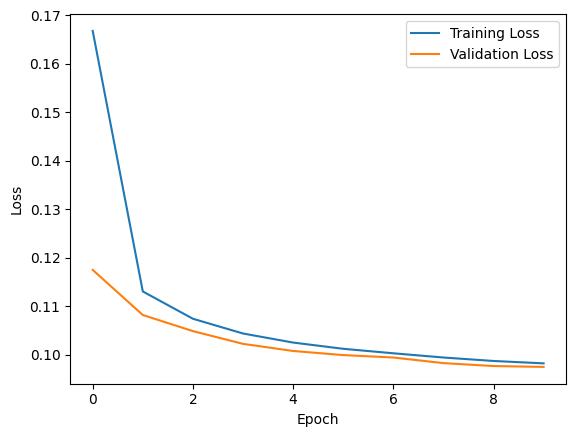

In [13]:
#Plot Training Loss
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [14]:
#Predict Denoising Images
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


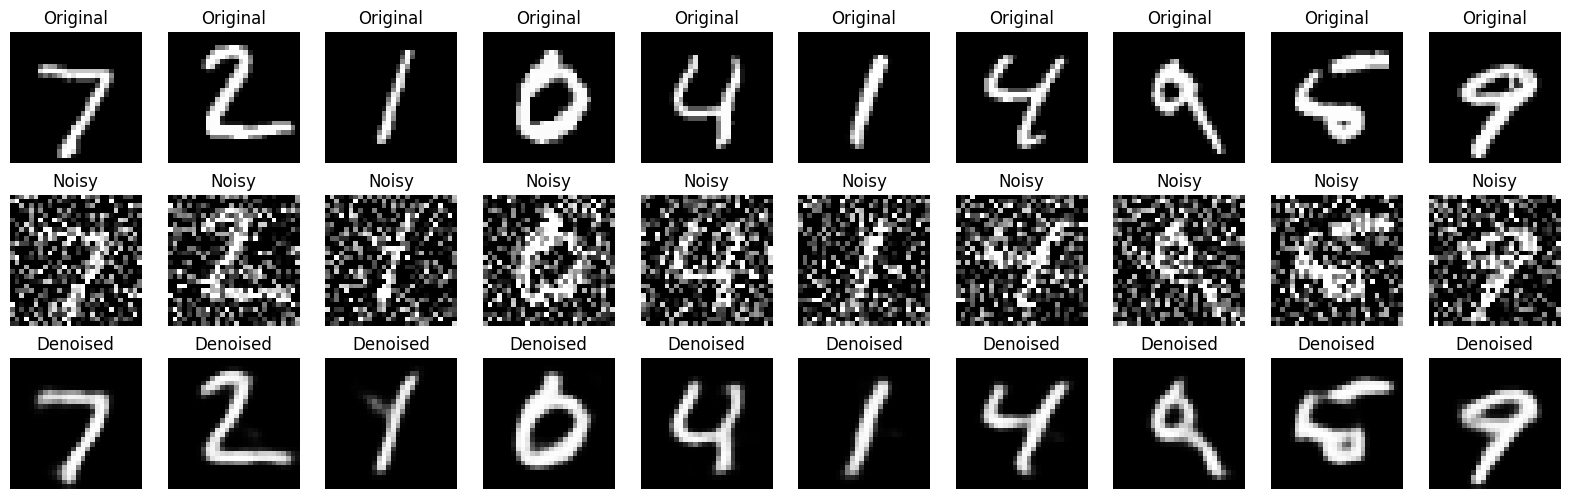

In [15]:
#Visualize Results
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Original

    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy

    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28),cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised

    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.show()

In [16]:
#Save
autoencoder.save("mnist_denoising_autoencoder.h5")